# Figure 3: Spectroscopic redshift-offset distributions

This notebook performs one task: generate the publication figure comparing aperture-selected BGS galaxies with matched redMaPPer member subsamples in bins of redMaPPer richness and BCG redshift.

In [3]:
from pathlib import Path
import pickle
import sys

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.modeling.polynomial import Chebyshev1D
from astropy.table import Table
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from specutils import Spectrum1D, SpectralRegion
from specutils.fitting import fit_generic_continuum

REPO_ROOT = Path('/global/homes/z/zzhang13/DESI/Projection')
if not REPO_ROOT.exists():
    REPO_ROOT = Path.cwd().resolve()
    while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'tools').exists():
        REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tools.richness_selection import make_redshift_offset_bins, make_z_bins

INPUT_CATALOG = REPO_ROOT / 'catalogs' / 'bgs_clus_RM_gal_matched_with_weights.pickle'
OUTPUT_FIGURE = REPO_ROOT / 'plots' / 'projection_richness_redshift_binned.png'
RICHNESS_BINS = [(20, 30), (30, 50), (50, 300)]
C_KMS = 2.99792458e5

print('Input:', INPUT_CATALOG)
print('Output:', OUTPUT_FIGURE)

Input: /global/homes/z/zzhang13/DESI/Projection/catalogs/bgs_clus_RM_gal_matched_with_weights.pickle
Output: /global/homes/z/zzhang13/DESI/Projection/plots/projection_richness_redshift_binned.png


In [21]:
def read_pickle_table(path):
    with Path(path).open('rb') as handle:
        obj = pickle.load(handle)
    if isinstance(obj, Table):
        return obj
    if obj.__class__.__module__.startswith('pandas'):
        return Table.from_pandas(obj)
    return Table(obj)


def normalized_redshift_offset(table):
    z_bgs = np.asarray(table['Z_BGS'], dtype=float)
    z_bcg = np.asarray(table['Z_SPEC_central'], dtype=float)
    return (z_bgs - z_bcg) / (1.0 + z_bcg)


def counts_per_cluster(table, edges):
    edges = np.asarray(edges, dtype=float)
    counts, _ = np.histogram(normalized_redshift_offset(table), bins=edges)
    widths = np.diff(edges)
    n_cluster = len(np.unique(np.asarray(table['ID'])))
    if n_cluster == 0:
        return np.full(len(widths), np.nan), np.full(len(widths), np.nan)
    density = counts / (widths * n_cluster)
    error = np.sqrt(counts) / (widths * n_cluster)
    error[counts == 0] = 0.1 / (widths[counts == 0] * n_cluster)
    return density, error


def fit_continuum(table, edges, centers):
    density, _ = counts_per_cluster(table, edges)
    spectrum = Spectrum1D(
        flux=density * u.Jy,
        spectral_axis=np.asarray(centers) * u.um,
    )
    model = fit_generic_continuum(
        spectrum,
        model=Chebyshev1D(6),
        median_window=7,
        exclude_regions=[SpectralRegion(-0.02 * u.um, 0.02 * u.um)],
    )
    return model(np.asarray(centers) * u.um).value


table = read_pickle_table(INPUT_CATALOG)
required = {'ID', 'LAMBDA', 'Z_BGS', 'Z_SPEC_central', 'central_flag', 'RM_gal_flag', 'P_member'}
missing = sorted(required.difference(table.colnames))
if missing:
    raise KeyError(f'Input catalog is missing required columns: {missing}')

table = table[~np.asarray(table['central_flag'], dtype=bool)]
zbin = make_redshift_offset_bins()
bin_boundaries = zbin.bin_boundaries
bin_centers = zbin.bin_centers
micro_boundaries = zbin.micro_bin_boundaries
micro_centers = zbin.micro_bin_centers
redshift_bins = [tuple(bounds) for bounds in make_z_bins()]

sample_masks = {
    'BGS galaxies': np.ones(len(table), dtype=bool),
    r'$p_{\rm mem} > 0.0$': (np.asarray(table['RM_gal_flag'], dtype=bool) & (np.asarray(table['P_member'], dtype=float) > 0.0)),
    r'$p_{\rm mem} > 0.8$': (np.asarray(table['RM_gal_flag'], dtype=bool) & (np.asarray(table['P_member'], dtype=float) > 0.8)),
}

print(f'Rows after removing central galaxies: {len(table):,}')
print(f'Clusters: {len(np.unique(np.asarray(table["ID"]))):,}')
print('Redshift bins:', redshift_bins)

Rows after removing central galaxies: 395,292
Clusters: 10,419
Redshift bins: [(0.1, 0.18), (0.18, 0.24), (0.24, 0.35)]


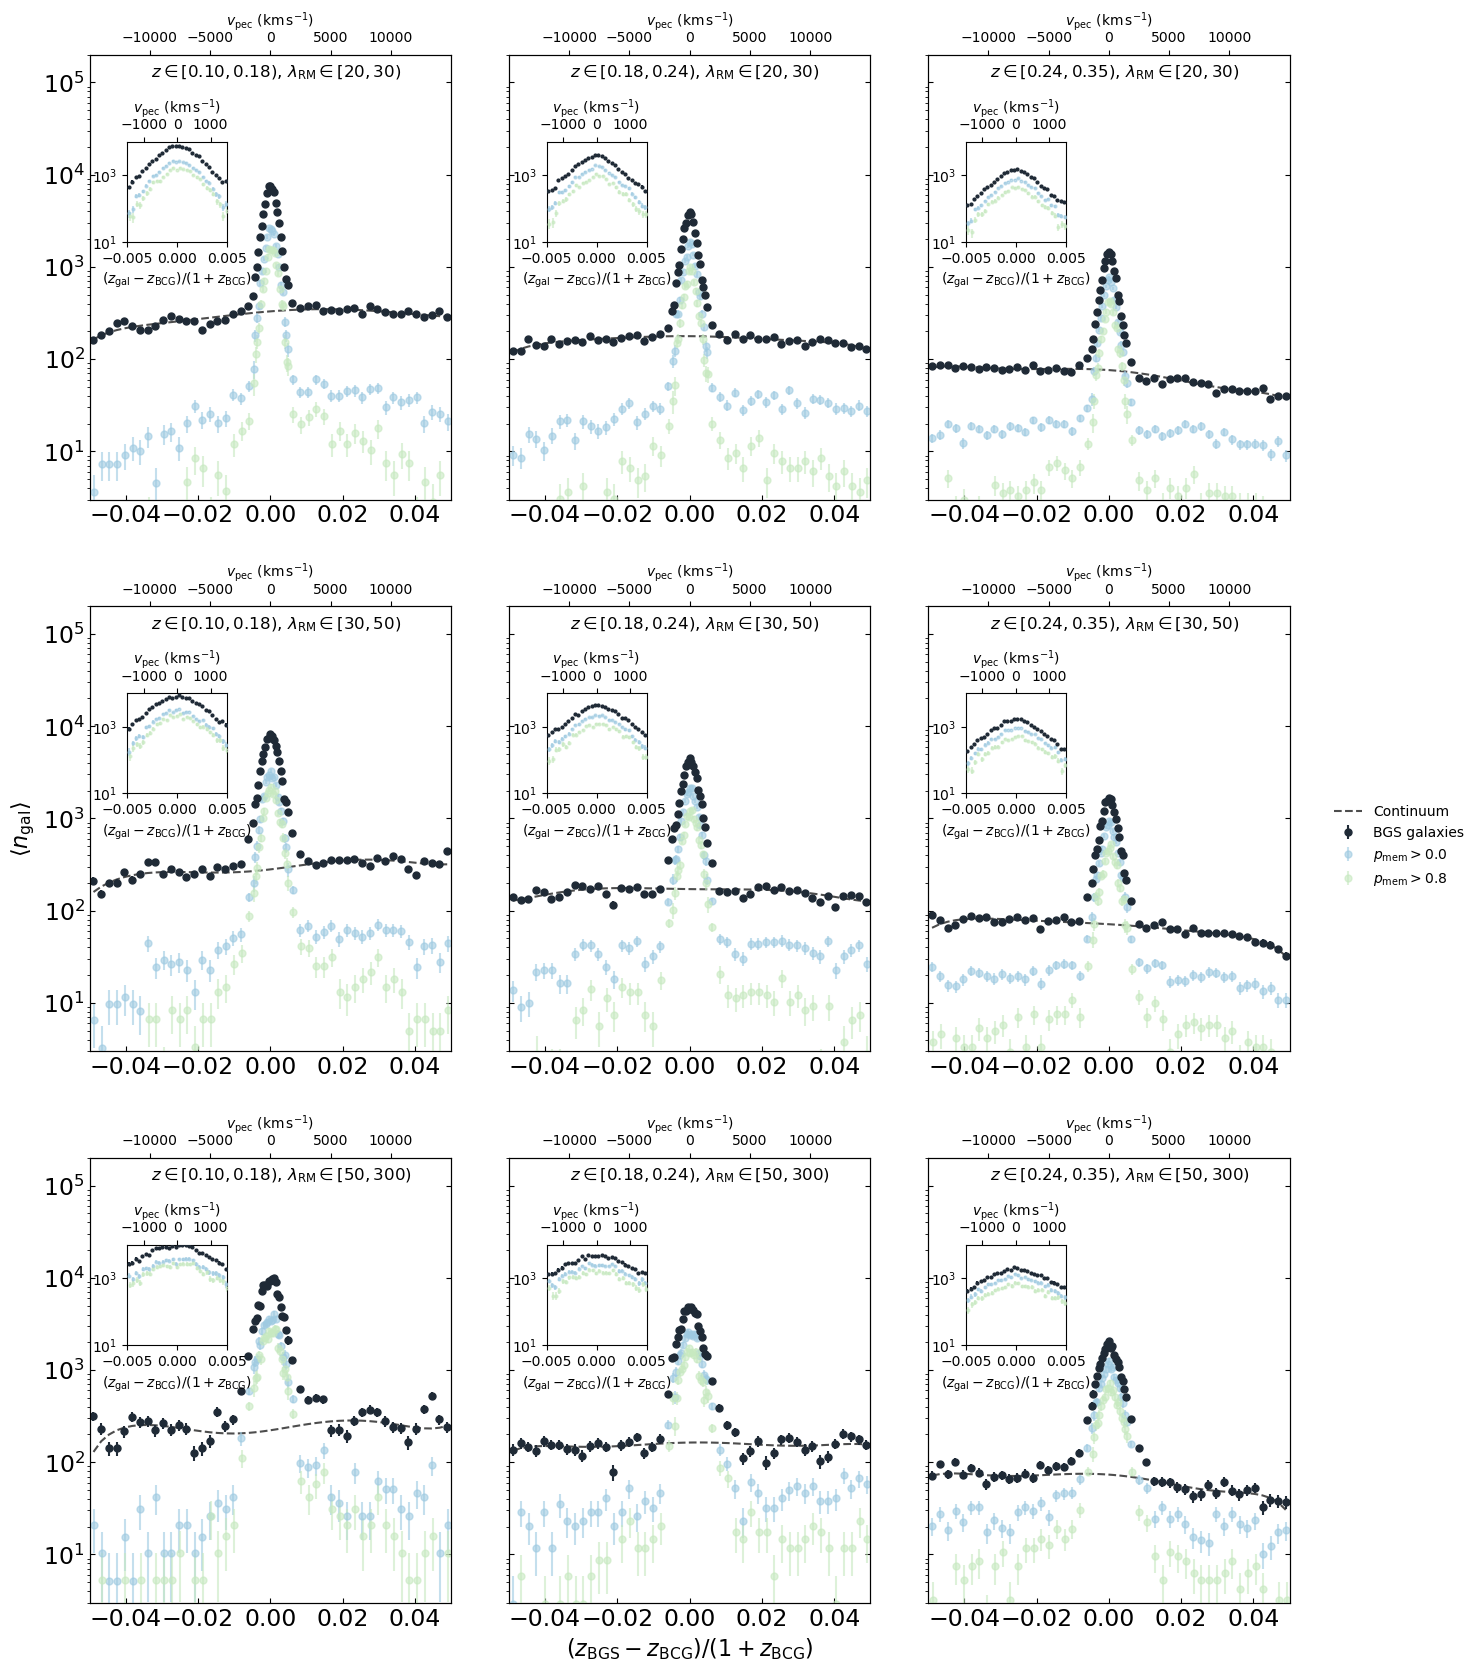

Saved /global/homes/z/zzhang13/DESI/Projection/plots/projection_richness_redshift_binned.png


In [22]:
fig, axes = plt.subplots(
    nrows=len(RICHNESS_BINS),
    ncols=len(redshift_bins),
    figsize=(16, 18),
    sharey=True,
)

colors = ['#1f2a36', '#9ecae1', '#c7e9c0']
sample_shift = 0.00012
inset_shift = 0.00005
fontsize = 12
labelsize = 16
legendsize = 10

for row, (lambda_low, lambda_high) in enumerate(RICHNESS_BINS):
    for col, (z_low, z_high) in enumerate(redshift_bins):
        ax = axes[row, col]
        panel_mask = (
            (np.asarray(table['LAMBDA'], dtype=float) >= lambda_low)
            & (np.asarray(table['LAMBDA'], dtype=float) < lambda_high)
            & (np.asarray(table['Z_SPEC_central'], dtype=float) >= z_low)
            & (np.asarray(table['Z_SPEC_central'], dtype=float) < z_high)
        )

        axins = inset_axes(
            ax,
            width=1.0,
            height=1.0,
            bbox_to_anchor=(0.10, 0.52, 0.3, 0.3),
            bbox_transform=ax.transAxes,
            loc='upper right',
        )
        axins_top = axins.twiny()

        for sample_index, ((label, sample_mask), color) in enumerate(zip(sample_masks.items(), colors)):
            current = table[panel_mask & sample_mask]
            if len(current) == 0:
                continue

            y, yerr = counts_per_cluster(current, bin_boundaries)
            y_micro, yerr_micro = counts_per_cluster(current, micro_boundaries)
            x = bin_centers + sample_index * sample_shift
            x_micro = micro_centers + sample_index * inset_shift
            zorder = 5 if label == 'BGS galaxies' else 3
            alpha = 1.0 if label == 'BGS galaxies' else 0.6

            ax.errorbar(
                x, y, yerr=yerr, linestyle='none', marker='o', markersize=5,
                alpha=alpha, color=color, zorder=zorder, label=label,
            )
            axins.errorbar(
                x_micro, y_micro, yerr=yerr_micro, linestyle='none', marker='o',
                markersize=2, alpha=alpha, color=color, zorder=zorder,
            )

            if label == 'BGS galaxies':
                continuum = fit_continuum(current, bin_boundaries, bin_centers)
                ax.plot(
                    bin_centers, continuum, color='#4d4d4d', linestyle='dashed',
                    label='Continuum',
                )

        ax.set_yscale('log')
        ax.set_xlim(-0.05, 0.05)
        ax.set_ylim(3, 2e5)
        ax.tick_params(axis='both', which='major', labelsize=17, direction='in', top=True, right=True)
        ax.text(
            0.17, 0.98,
            rf'$z \in [{z_low:.2f},{z_high:.2f})$, $\lambda_{{\rm RM}} \in [{lambda_low},{lambda_high})$',
            transform=ax.transAxes, fontsize=fontsize, ha='left', va='top',
        )

        ax_top = ax.twiny()
        ax_top.set_xlim(np.asarray(ax.get_xlim()) * C_KMS)
        ax_top.set_xlabel(r'$v_{\rm pec}\ ({\rm km\,s^{-1}})$')
        axins.set_xlim(-0.005, 0.005)
        axins.set_ylim(10, 1.0e4)
        axins.set_yscale('log')
        axins.set_xlabel(r'$(z_{\rm gal}-z_{\rm BCG})/(1+z_{\rm BCG})$')
        axins_top.set_xlim(np.asarray(axins.get_xlim()) * C_KMS)
        axins_top.set_xlabel(r'$v_{\rm pec}\ ({\rm km\,s^{-1}})$')


# Collect unique legend entries across all nine panels.
legend_entries = {}

for ax in axes.flat:
    handles, labels = ax.get_legend_handles_labels()

    for handle, label in zip(handles, labels):
        if label and label not in legend_entries:
            legend_entries[label] = handle

# Leave room on the right for the external legend.
fig.subplots_adjust(
    left=0.08,
    right=0.83,
    bottom=0.08,
    top=0.94,
    hspace=0.24,
    wspace=0.16,
)

fig.legend(
    legend_entries.values(),
    legend_entries.keys(),
    loc="center left",
    bbox_to_anchor=(0.85, 0.50),
    frameon=False,
    fontsize=legendsize,
)

axes[1, 0].set_ylabel(r'$\langle n_{\rm gal} \rangle$', fontsize=labelsize)
axes[-1, 1].set_xlabel(r'$(z_{\rm BGS}-z_{\rm BCG})/(1+z_{\rm BCG})$', fontsize=labelsize)

fig.subplots_adjust(hspace=0.24, wspace=0.16)
OUTPUT_FIGURE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_FIGURE, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_FIGURE}')